https://mapping.emergency.copernicus.eu/activations/EMSN068/

In [1]:
# Install Dependencies
!pip install geopandas osmnx networkx shapely pyproj -q
!pip install mapclassify -q
!pip install gdown -q
!apt-get install -y osmctools
!pip install ogr2osm

print("installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.2 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  osmctools
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 155 kB of archives.
After this operation, 443 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 osmctools amd64 0.9-3 [155 kB]
Fetched 155 kB in 1s (167 kB/s)
Selecting previously unselected package osmctools.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../osmctools_0.9-3_amd64.deb ...
Unpacking osmctools (0.9-3) ...
Setting up osmctools (0.9-3) ...
Processing triggers for man-db (2.10.2-1) ...
  Preparing metadata (setup.py) ... done
  Created wheel for ogr2osm: filename=ogr2osm-1.2.1-py3-none-any.whl size=30944 sha256=74126418f52de82362545147528e82790a6884254f3e7cf771e2053a9aed77

In [2]:
# Import Libraries
import geopandas as gpd
import pandas as pd
import numpy as np
import osmnx as ox
import networkx as nx
from shapely.geometry import Point, Polygon, MultiPolygon, box
from shapely.ops import unary_union
import matplotlib.pyplot as plt
import warnings
from scipy.spatial import cKDTree
from google.colab import files
warnings.filterwarnings('ignore')

TARGET_CRS = "EPSG:25832"  # UTM zone 32N for Germany
WGS84_CRS = "EPSG:4326"

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
#download copernicus floodmask shapefile (brandenburg emsn068)
import gdown

url = "https://drive.google.com/drive/folders/1zAQled7hN-JVr2FheBotKvRfY3WiUHVs"
gdown.download_folder(url, output="/content/flood_mask", quiet=False)

Retrieving folder contents


Processing file 1hXBXbCeR0laDTN8Ii2CWYZLMjiVvwJRn EMSN068_copernicus_Brandenburg flood mapping.cpg
Processing file 1n0LkbKyjpeqtn1oZ24XUEKhMUjwBwR1m EMSN068_copernicus_Brandenburg flood mapping.dbf
Processing file 1gbRqFgUmm16NulOvRLbJKX1l2om1wdgK EMSN068_copernicus_Brandenburg flood mapping.prj
Processing file 1W68LvXjG4_bJpGVldxgDJsnIDIjLXxBK EMSN068_copernicus_Brandenburg flood mapping.qmd
Processing file 15aYNiJQnY5weMALt51qBFACZUi2xihKU EMSN068_copernicus_Brandenburg flood mapping.shp
Processing file 1Sc2P8TabpT25rjKTVlMxFYvwjXbSP0gR EMSN068_copernicus_Brandenburg flood mapping.shx


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1hXBXbCeR0laDTN8Ii2CWYZLMjiVvwJRn
To: /content/flood_mask/EMSN068_copernicus_Brandenburg flood mapping.cpg
100%|██████████| 5.00/5.00 [00:00<00:00, 12.0kB/s]
Downloading...
From: https://drive.google.com/uc?id=1n0LkbKyjpeqtn1oZ24XUEKhMUjwBwR1m
To: /content/flood_mask/EMSN068_copernicus_Brandenburg flood mapping.dbf
100%|██████████| 60.1M/60.1M [00:00<00:00, 84.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1gbRqFgUmm16NulOvRLbJKX1l2om1wdgK
To: /content/flood_mask/EMSN068_copernicus_Brandenburg flood mapping.prj
100%|██████████| 401/401 [00:00<00:00, 1.23MB/s]
Downloading...
From: https://drive.google.com/uc?id=1W68LvXjG4_bJpGVldxgDJsnIDIjLXxBK
To: /content/flood_mask/EMSN068_copernicus_Brandenburg flood mapping.qmd
100%|██████████| 2.35k/2.35k [00:00<00:00, 7.20MB/s]
Downloading...
From: https://drive.google.com/uc?id=1

['/content/flood_mask/EMSN068_copernicus_Brandenburg flood mapping.cpg',
 '/content/flood_mask/EMSN068_copernicus_Brandenburg flood mapping.dbf',
 '/content/flood_mask/EMSN068_copernicus_Brandenburg flood mapping.prj',
 '/content/flood_mask/EMSN068_copernicus_Brandenburg flood mapping.qmd',
 '/content/flood_mask/EMSN068_copernicus_Brandenburg flood mapping.shp',
 '/content/flood_mask/EMSN068_copernicus_Brandenburg flood mapping.shx']

Shape: (198254, 10)
CRS: EPSG:32633


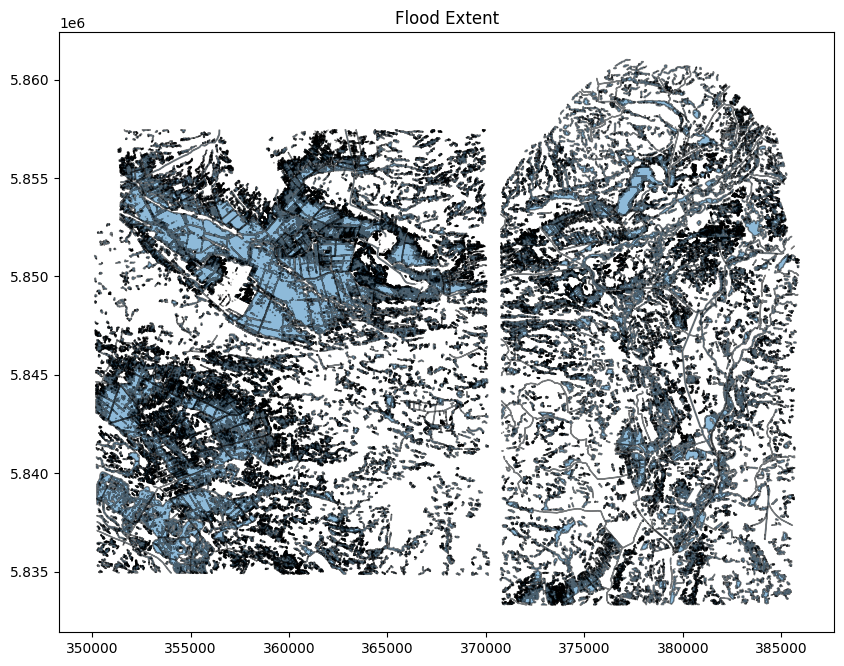

In [4]:

# Load Shapefile and Check Attributes

SHAPEFILE_PATH = '/content/flood_mask/EMSN068_copernicus_Brandenburg flood mapping.shp'
flood_gdf = gpd.read_file(SHAPEFILE_PATH)

print(f"Shape: {flood_gdf.shape}")
print(f"CRS: {flood_gdf.crs}")
flood_gdf.head()
flood_gdf.plot(figsize=(10, 8), edgecolor='black', alpha=0.5)
plt.title("Flood Extent")
plt.show()

In [5]:
# Download OSM Buildings dump from Geofabrik
!wget -q --show-progress https://download.geofabrik.de/europe/germany/brandenburg-latest-free.shp.zip
!unzip -q brandenburg-latest-free.shp.zip -d /content/brandenburg_osm

print("Downloaded and extracted")

brandenburg-latest- 100%[===================>] 452.12M  8.48MB/s    in 59s     
Downloaded and extracted


In [6]:

# Load Buildings in Flood Bbox

flood_wgs84 = flood_gdf.to_crs("EPSG:4326")
minx, miny, maxx, maxy = flood_wgs84.total_bounds

# Load all buildings within bbox
buildings_gdf = gpd.read_file(
    '/content/brandenburg_osm/gis_osm_buildings_a_free_1.shp',
    bbox=(minx, miny, maxx, maxy)
)

buildings_gdf['building_type'] = buildings_gdf['type'].fillna('unknown')

print(f" {len(buildings_gdf)} buildings in flood bbox")
print(buildings_gdf['building_type'].value_counts().head(10))

 77115 buildings in flood bbox
building_type
unknown               55044
house                  8990
detached               3407
residential            1870
garage                 1325
apartments             1073
terrace                 988
semidetached_house      696
allotment_house         634
commercial              467
Name: count, dtype: int64


total 44596
drwxr-xr-x 2 root root     4096 Jul 20 08:55 .
drwxr-xr-x 1 root root     4096 Jul 20 08:55 ..
-rw-r--r-- 1 root root        5 Jul 20 08:55 buildings_flood_bbox.cpg
-rw-r--r-- 1 root root 33005446 Jul 20 08:55 buildings_flood_bbox.dbf
-rw-r--r-- 1 root root      145 Jul 20 08:55 buildings_flood_bbox.prj
-rw-r--r-- 1 root root 12024384 Jul 20 08:55 buildings_flood_bbox.shp
-rw-r--r-- 1 root root   617020 Jul 20 08:55 buildings_flood_bbox.shx


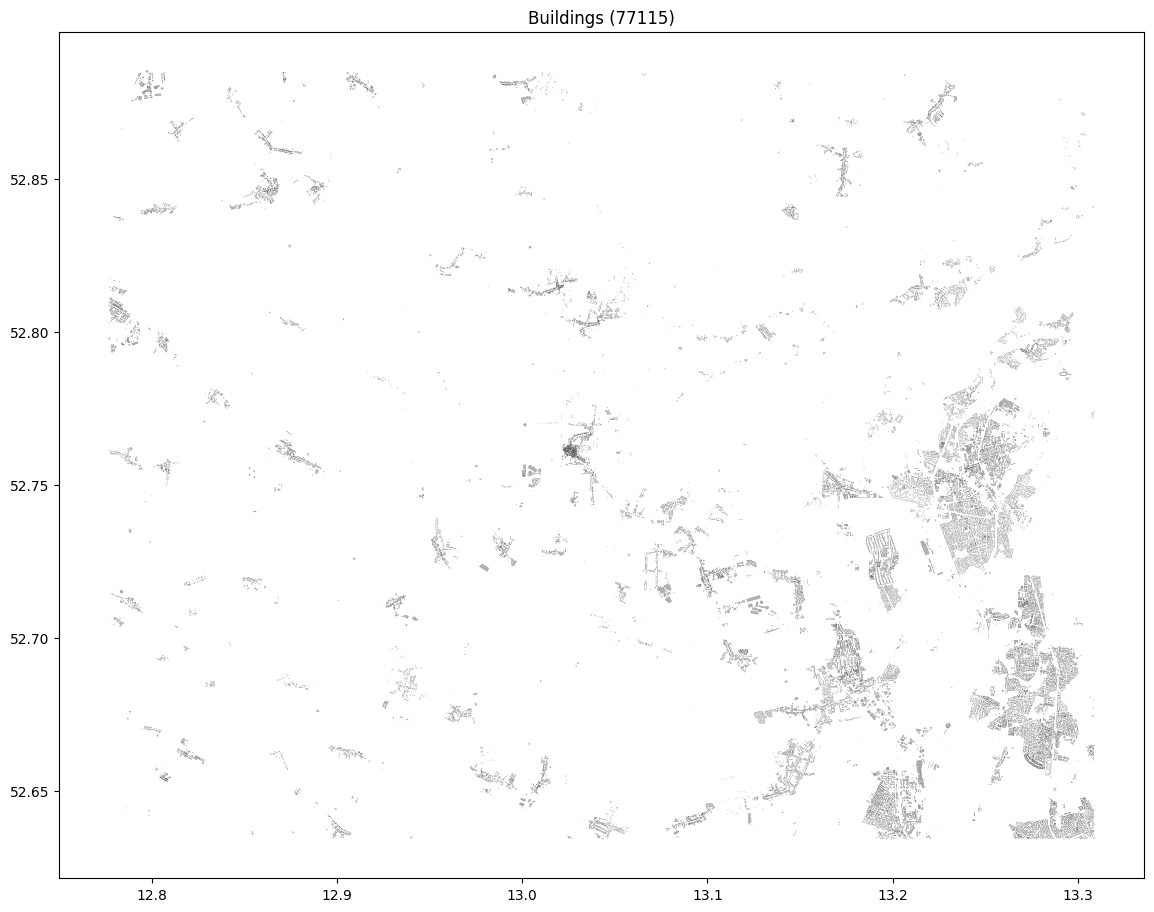

In [7]:

# Visualize Buildings footprint


# Create folder and save
!mkdir -p /content/buildings
buildings_gdf.to_file('/content/buildings/buildings_flood_bbox.shp')

# Verify files
!ls -la /content/buildings/

# Plot
fig, ax = plt.subplots(figsize=(14, 12))
buildings_gdf.plot(ax=ax, color='gray', alpha=0.6, edgecolor='black', linewidth=0.1)
plt.title(f"Buildings ({len(buildings_gdf)})")
plt.show()

In [8]:
# Build Scene Graph
# ReprReprojectoject
buildings_utm = buildings_gdf.to_crs("EPSG:25832").reset_index(drop=True)
buildings_utm['bid'] = [f"B_{i}" for i in range(len(buildings_utm))]
buildings_utm['wkt'] = buildings_utm.geometry.to_wkt()

flood_utm = flood_gdf.to_crs("EPSG:25832").reset_index(drop=True)
flood_utm['fid'] = [f"F_{i}" for i in range(len(flood_utm))]
flood_utm['wkt'] = flood_utm.geometry.to_wkt()

# Buffer flood polygons for classification
print("Buffering flood")
flood_10m = flood_utm.copy(); flood_10m.geometry = flood_utm.buffer(10)
flood_50m = flood_utm.copy(); flood_50m.geometry = flood_utm.buffer(50)

# Spatial joins for flood status classification
print("Spatial joins")
drowned_pairs = gpd.sjoin(buildings_utm[['bid','geometry']], flood_utm[['fid','geometry']],  predicate='intersects')[['bid','fid']]
close_pairs   = gpd.sjoin(buildings_utm[['bid','geometry']], flood_10m[['fid','geometry']], predicate='intersects')[['bid','fid']]
at_risk_pairs = gpd.sjoin(buildings_utm[['bid','geometry']], flood_50m[['fid','geometry']], predicate='intersects')[['bid','fid']]

# Classification sets
drowned_set = set(drowned_pairs['bid'].unique())
close_set   = set(close_pairs['bid'].unique()) - drowned_set
risk_set    = set(at_risk_pairs['bid'].unique()) - drowned_set - close_set
safe        = len(buildings_utm) - len(drowned_set) - len(close_set) - len(risk_set)
print(f"Drowned:  {len(drowned_set)}")
print(f"Close_to: {len(close_set)}")
print(f"At_risk:  {len(risk_set)}")
print(f"Safe:     {safe}")
print(f"Total:    {len(buildings_utm)}")

# Build graph
print("Building graph")
G = nx.Graph()

# Add flood polygon nodes
for _, row in flood_utm.iterrows():
    G.add_node(row['fid'], node_type='flood_polygon', wkt=row['wkt'])

# Add building nodes with flood_status embedded
for _, row in buildings_utm.iterrows():
    bid = row['bid']
    status = (
        'drowned'  if bid in drowned_set else
        'close_to' if bid in close_set   else
        'at_risk'  if bid in risk_set    else
        'safe'
    )
    G.add_node(bid, node_type='building', building_type=row['building_type'],
               flood_status=status, wkt=row['wkt'])

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Buffering flood
Spatial joins
Drowned:  7018
Close_to: 5454
At_risk:  16711
Safe:     47932
Total:    77115
Building graph
Graph: 275369 nodes, 0 edges


In [9]:
!apt-get install -y osmium-tool

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libboost-program-options1.74.0
The following NEW packages will be installed:
  libboost-program-options1.74.0 osmium-tool
0 upgraded, 2 newly installed, 0 to remove and 3 not upgraded.
Need to get 882 kB of archives.
After this operation, 3,863 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libboost-program-options1.74.0 amd64 1.74.0-14ubuntu3 [311 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 osmium-tool amd64 1.14.0-1 [571 kB]
Fetched 882 kB in 1s (674 kB/s)
Selecting previously unselected package libboost-program-options1.74.0:amd64.
(Reading database ... 118253 files and directories currently installed.)
Preparing to unpack .../libboost-program-options1.74.0_1.74.0-14ubuntu3_amd64.deb ...
Unpacking libboost-program-options1.74.0:amd64 (1.74.0-14ubuntu3) ...
Selecti

In [10]:
!wget -q --show-progress \
  https://download.geofabrik.de/europe/germany/brandenburg-latest.osm.pbf \
  -O /content/brandenburg.osm.pbf


/content/brandenbur 100%[===================>] 284.06M  10.6MB/s    in 31s     


In [11]:
minx, miny, maxx, maxy = flood_utm.to_crs('EPSG:4326').total_bounds
!osmium extract --bbox {minx-0.001},{miny-0.001},{maxx+0.001},{maxy+0.001} /content/brandenburg.osm.pbf -o /content/study_area.osm.pbf --overwrite
!osmium cat /content/study_area.osm.pbf -o /content/study_area.osm --overwrite


In [58]:
# ─────────────────────────────────────────────────────────────────────────────
# Road network + surgical flood cut + compose
# ─────────────────────────────────────────────────────────────────────────────
from shapely.geometry import LineString
from shapely.strtree import STRtree
from shapely.ops import substring
import numpy as np

def cut_flooded_edges(G_simple, flood_polys, flood_tree):
    """
    Surgical flood cut using STRtree spatial index.

    For each road edge that touches the flood:
      - STRtree finds the 2-3 candidate polygons near that edge.
      - For each candidate polygon, finds exact entry/exit points
        on the edge geometry independently (no unary_union).
      - Handles Point, MultiPoint, LineString and GeometryCollection
        boundary intersections correctly.
      - Cuts the edge at those points and inserts CUT_ nodes.
      - Classifies each subsegment by checking if its midpoint
        is inside ANY of the candidate polygons.
    Edges that do not touch the flood are never modified.
    """
    G_out = G_simple.copy()

    # Collect only road_segment edges with geometry
    road_edges = [
        (u, v, data)
        for u, v, data in G_simple.edges(data=True)
        if data.get('relation') == 'road_segment' and data.get('geometry') is not None
    ]

    # Bulk spatial query — find which edges touch any flood polygon at all
    geom_list = [data['geometry'] for _, _, data in road_edges]
    pairs = flood_tree.query(geom_list, predicate='intersects')

    # Group polygon candidates by edge index
    edge_to_polys = {}
    for edge_idx, poly_idx in zip(pairs[0], pairs[1]):
        edge_to_polys.setdefault(int(edge_idx), []).append(int(poly_idx))

    print(f"  Edges touching flood: {len(edge_to_polys)} / {len(road_edges)}")

    def extract_cut_distances(geom, boundary_isect):
        """
        Extract projected distances from any boundary intersection type.
        Handles Point, MultiPoint, LineString, MultiLineString,
        GeometryCollection and any combination thereof.
        """
        distances = set()

        def _add_point(pt):
            distances.add(round(geom.project(pt), 6))

        def _add_linestring(ls):
            # Use both endpoints of the line as cut points
            _add_point(ls.interpolate(0, normalized=True))
            _add_point(ls.interpolate(1, normalized=True))

        def _process(g):
            t = g.geom_type
            if t == 'Point':
                _add_point(g)
            elif t == 'MultiPoint':
                for pt in g.geoms:
                    _add_point(pt)
            elif t == 'LineString':
                _add_linestring(g)
            elif t in ('MultiLineString', 'GeometryCollection'):
                for part in g.geoms:
                    _process(part)  # recurse for nested collections

        if not boundary_isect.is_empty:
            _process(boundary_isect)

        return distances

    # Process only flooded edges
    for edge_idx, poly_idxs in edge_to_polys.items():
        u, v, data = road_edges[edge_idx]
        geom = data['geometry']
        poly_list = [flood_polys[i] for i in poly_idxs]

        # ── Verify geometry orientation against (u, v) node order ────────────
        # When a MultiDiGraph is converted to a simple Graph, NetworkX may store
        # an edge as (u, v) or (v, u) regardless of the original direction.
        # If the geometry runs v→u instead of u→v, geom.interpolate(0) would map
        # to node v — causing CUT_ nodes to be connected to the wrong endpoint.
        # Invert the coordinates when needed so that geom.coords[0] always
        # corresponds to node u.
        u_data = G_simple.nodes[u]
        v_data = G_simple.nodes[v]
        if 'x' in u_data and 'x' in v_data:
            gx0, gy0 = geom.coords[0]
            dist_u = (u_data['x'] - gx0)**2 + (u_data['y'] - gy0)**2
            dist_v = (v_data['x'] - gx0)**2 + (v_data['y'] - gy0)**2
            if dist_v < dist_u:
                geom = LineString(list(geom.coords)[::-1])


        # Collect cut points from each polygon independently
        cut_distances = set()
        for poly in poly_list:
            boundary_isect = geom.intersection(poly.boundary)
            cut_distances |= extract_cut_distances(geom, boundary_isect)

        # If no cut points found, edge is fully inside flood — mark and move on
        if not cut_distances:
            G_out[u][v]['flooded'] = True
            continue

        cut_distances = sorted(cut_distances)
        all_distances = [0.0] + cut_distances + [geom.length]

        node_ids = (
            [u]
            + [f"CUT_{u}_{v}_{i}" for i in range(len(cut_distances))]
            + [v]
        )

        # Add intermediate cut nodes
        for i, nid in enumerate(node_ids):
            if nid not in G_out:
                pt = geom.interpolate(all_distances[i])
                G_out.add_node(nid, x=pt.x, y=pt.y, wkt=pt.wkt,
                               node_type='road_node', osmid=nid)

        # Replace original edge with subsegments
        G_out.remove_edge(u, v)

        for i in range(len(all_distances) - 1):
            d_start  = all_distances[i]
            d_end    = all_distances[i + 1]
            seg_geom = substring(geom, d_start, d_end)

            # Flooded if midpoint is inside ANY candidate polygon
            midpt      = geom.interpolate((d_start + d_end) / 2)
            is_flooded = any(poly.contains(midpt) for poly in poly_list)

            seg_data = {
                **data,
                'geometry': seg_geom,
                'length':   round(seg_geom.length, 2),
                'flooded':  is_flooded
            }
            G_out.add_edge(node_ids[i], node_ids[i + 1], **seg_data)

    return G_out


# ── Precompute building centroids ─────────────────────────────────────────────
building_coords = np.column_stack([
    buildings_utm.geometry.centroid.x.values,
    buildings_utm.geometry.centroid.y.values
])
bids = buildings_utm['bid'].tolist()

# ── Download and project road network ────────────────────────────────────────
G_streets = ox.graph_from_xml('/content/study_area.osm', retain_all=True, simplify=True)
G_streets.graph['crs'] = 'EPSG:4326'
G_streets = ox.convert.to_undirected(G_streets)
G_streets = ox.project_graph(G_streets, to_crs='EPSG:25832')

nodes_gdf, edges_gdf = ox.convert.graph_to_gdfs(G_streets)

if edges_gdf.total_bounds[0] < 180:
    edges_gdf = edges_gdf.set_crs("EPSG:4326", allow_override=True).to_crs("EPSG:25832")
    nodes_gdf = nodes_gdf.set_crs("EPSG:4326", allow_override=True).to_crs("EPSG:25832")

nodes_gdf['wkt'] = nodes_gdf.geometry.to_wkt()
nx.set_node_attributes(G_streets, nodes_gdf['wkt'].to_dict(),            name='wkt')
nx.set_node_attributes(G_streets, nodes_gdf.index.to_series().to_dict(), name='osmid')
nx.set_node_attributes(G_streets, 'road_node',                           name='node_type')

# ── Convert to simple Graph and relabel nodes ─────────────────────────────────
G_streets = nx.relabel_nodes(G_streets, {n: f"R{n}" for n in G_streets.nodes})
G_streets_simple = nx.Graph(G_streets)
nx.set_edge_attributes(G_streets_simple, 'road_segment', name='relation')
nx.set_edge_attributes(G_streets_simple, False,          name='flooded')

# ── Build spatial index once ──────────────────────────────────────────────────
flood_polys = list(flood_utm.geometry)
flood_tree  = STRtree(flood_polys)

# ── Apply surgical cut ────────────────────────────────────────────────────────
G_streets_cut = cut_flooded_edges(G_streets_simple, flood_polys, flood_tree)

n_new_nodes = G_streets_cut.number_of_nodes() - G_streets_simple.number_of_nodes()
n_new_edges = G_streets_cut.number_of_edges() - G_streets_simple.number_of_edges()
flooded_count = sum(1 for _, _, d in G_streets_cut.edges(data=True) if d.get('flooded'))

print(f"New cut nodes inserted:  {n_new_nodes}")
print(f"Net new edges created:   {n_new_edges}")
print(f"Flooded subsegments:     {flooded_count}")

# ── Compose into the main graph G (single graph, no subgraphs) ───────────────
G = nx.compose(G, G_streets_cut)

# ── cKDTree over all nodes of the cut network ─────────────────────────────────
road_ids_cut = [
    nid for nid, data in G_streets_cut.nodes(data=True)
    if 'x' in data and np.isfinite(data['x']) and np.isfinite(data.get('y', float('nan')))
]
road_coords_cut = np.array([
    [G_streets_cut.nodes[n]['x'], G_streets_cut.nodes[n]['y']]
    for n in road_ids_cut
])

road_tree = cKDTree(road_coords_cut)
dists, idxs = road_tree.query(building_coords)
G.add_edges_from([
    (bid, road_ids_cut[idx], {'relation': 'accesses', 'length': round(float(dist), 2)})
    for bid, dist, idx in zip(bids, dists, idxs)
])

print(f"Valid road nodes (post-cut): {len(road_ids_cut)}")
print(f"Final graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

  Edges touching flood: 36329 / 181088
New cut nodes inserted:  108903
Net new edges created:   108903
Flooded subsegments:     75250
Valid road nodes (post-cut): 306084
Final graph: 581453 nodes, 367106 edges


# COPY OF FINAL GRAPH BEFORE ADDING FLOOD PENALTIES

In [59]:
# =====================================================
# COPY OF FINAL GRAPH BEFORE ADDING FLOOD PENALTIES
# =====================================================

G_no_flood = G.copy()

print("Graph without flood penalty copied successfully.")
print(f"Nodes in G_no_flood: {G_no_flood.number_of_nodes()}")
print(f"Edges in G_no_flood: {G_no_flood.number_of_edges()}")

Graph without flood penalty copied successfully.
Nodes in G_no_flood: 581453
Edges in G_no_flood: 367106


# Add routing_cost to graph

In [60]:
# Add routing_cost to graph

INF = float("inf")

for _, _, data in G.edges(data=True):
    relation = data.get("relation")
    length = data.get("length")
    flooded = data.get("flooded", False)

    # Ensure length is numeric when available
    if length is not None:
        try:
            length = float(length)
        except (TypeError, ValueError):
            length = None

    # Road segments become impassable if flooded
    if relation == "road_segment":
        data["routing_cost"] = INF if flooded or length is None else length

    # All other edges remain usable if length is available
    else:
        data["routing_cost"] = INF if length is None else length

print("routing_cost assigned successfully")

routing_cost assigned successfully


# Part 2

In [61]:
# =====================================================
# Part 2A - Build reusable analytical tables
# =====================================================

from shapely import wkt
from shapely.geometry import Point
import pandas as pd


def _safe_float_local(value, default=0.0):
    try:
        return float(value)
    except (TypeError, ValueError):
        return default


def _get_node_point_local(graph, node_id):
    """
    Return a representative point for a node.
    Building nodes use their centroid. Road nodes use x/y when available.
    """
    node_data = graph.nodes[node_id]

    geom_wkt = node_data.get("wkt")
    if geom_wkt is not None:
        geom = wkt.loads(geom_wkt) if isinstance(geom_wkt, str) else geom_wkt
        return geom if geom.geom_type == "Point" else geom.centroid

    if "x" in node_data and "y" in node_data:
        return Point(node_data["x"], node_data["y"])

    raise ValueError(f"Node {node_id} has no usable geometry.")


# ---------------------------------
# 1) Master building table
# ---------------------------------
building_rows = []

for node_id, data in G.nodes(data=True):
    is_building = str(node_id).startswith("B_") or data.get("node_type") == "building"
    if not is_building:
        continue

    geom_wkt = data.get("wkt")
    if not geom_wkt:
        continue

    try:
        geom = wkt.loads(geom_wkt)
    except Exception:
        continue

    centroid = geom.centroid

    building_rows.append({
        "building_id": node_id,
        "building_type": data.get("building_type", "unknown"),
        "flood_status": data.get("flood_status", "unknown"),
        "x": centroid.x,
        "y": centroid.y
    })

buildings_df = (
    pd.DataFrame(building_rows)
    .sort_values("building_id")
    .reset_index(drop=True)
)

print(f"Building nodes with valid geometry: {len(buildings_df)}")
print("\nFlood status counts:")
print(buildings_df["flood_status"].value_counts(dropna=False))


# ---------------------------------
# 2) Reusable road segment index table
# ---------------------------------
road_segment_rows = []

for u, v, edge_data in G.edges(data=True):
    if edge_data.get("relation") != "road_segment":
        continue

    geom_raw = edge_data.get("geometry")
    has_geometry = geom_raw is not None

    minx = miny = maxx = maxy = None

    if has_geometry:
        try:
            geom = wkt.loads(geom_raw) if isinstance(geom_raw, str) else geom_raw
            minx, miny, maxx, maxy = geom.bounds
        except Exception:
            has_geometry = False

    if not has_geometry:
        try:
            p1 = _get_node_point_local(G, u)
            p2 = _get_node_point_local(G, v)

            minx = min(p1.x, p2.x)
            miny = min(p1.y, p2.y)
            maxx = max(p1.x, p2.x)
            maxy = max(p1.y, p2.y)
        except Exception:
            continue

    road_segment_rows.append({
        "from_node": u,
        "to_node": v,
        "relation": "road_segment",
        "flooded": edge_data.get("flooded", False),
        "length_m": _safe_float_local(edge_data.get("length"), default=0.0),
        "has_geometry": has_geometry,
        "minx": minx,
        "miny": miny,
        "maxx": maxx,
        "maxy": maxy
    })

road_segments_index_df = (
    pd.DataFrame(road_segment_rows)
    .sort_values(["from_node", "to_node"])
    .reset_index(drop=True)
)

print(f"\nIndexed road segments: {len(road_segments_index_df)}")
print(f"Flooded road segments in index: {int(road_segments_index_df['flooded'].sum())}")
print(f"Road segments with stored geometry: {int(road_segments_index_df['has_geometry'].sum())}")

Building nodes with valid geometry: 77115

Flood status counts:
flood_status
safe        47932
at_risk     16711
drowned      7018
close_to     5454
Name: count, dtype: int64

Indexed road segments: 289991
Flooded road segments in index: 75250
Road segments with stored geometry: 289991


In [62]:
# =====================================================
# Part 2B - Define source and target pools
# =====================================================

SOURCE_STATUS_FILTER = ["close_to"]
TARGET_STATUS_FILTER = ["safe"]

N_SOURCE_SHOW = 30
SOURCE_OFFSET = 0

source_candidates_df = (
    buildings_df[buildings_df["flood_status"].isin(SOURCE_STATUS_FILTER)]
    .sort_values(["flood_status", "building_id"])
    .reset_index(drop=True)
    .copy()
)

target_pool_df = (
    buildings_df[buildings_df["flood_status"].isin(TARGET_STATUS_FILTER)]
    .sort_values("building_id")
    .reset_index(drop=True)
    .copy()
)

print(f"Source candidates: {len(source_candidates_df)}")
print(f"Target pool: {len(target_pool_df)}")

source_preview_df = source_candidates_df.iloc[SOURCE_OFFSET:SOURCE_OFFSET + N_SOURCE_SHOW].copy()

print(f"\nShowing source candidates from row {SOURCE_OFFSET} to {SOURCE_OFFSET + len(source_preview_df) - 1}")
print(
    source_preview_df[
        ["building_id", "flood_status", "building_type"]
    ].to_string(index=False)
)

Source candidates: 5454
Target pool: 47932

Showing source candidates from row 0 to 29
building_id flood_status building_type
     B_1006     close_to       unknown
    B_10102     close_to       unknown
    B_10119     close_to       unknown
    B_10127     close_to       unknown
     B_1013     close_to      detached
     B_1015     close_to       unknown
    B_10155     close_to       unknown
    B_10164     close_to          farm
     B_1020     close_to       unknown
     B_1022     close_to       unknown
     B_1023     close_to      detached
    B_10270     close_to       unknown
     B_1028     close_to       unknown
    B_10285     close_to       unknown
    B_10299     close_to       unknown
    B_10300     close_to       unknown
    B_10313     close_to         house
     B_1034     close_to       unknown
    B_10343     close_to       unknown
     B_1036     close_to       unknown
    B_10466     close_to         house
     B_1049     close_to       unknown
      B_105     

In [63]:
import math
import networkx as nx

# =====================================================
# Part 2C - Explore reachable target candidates
# =====================================================
# This block is only for scenario selection.
# The final routing in Part 3 will use A* on G and G_no_flood.

exploration_source_building = "B_10731"

TOP_K = 10
MIN_TARGET_DISTANCE_M = 3000      # e.g. 3000
MAX_TARGET_DISTANCE_M = None      # e.g. 4000
SORT_ASCENDING = True             # True = nearest first, False = farthest first

if exploration_source_building not in set(source_candidates_df["building_id"]):
    raise ValueError(
        f"{exploration_source_building} is not a valid source candidate."
    )

# One single-source Dijkstra run is efficient here because we want to rank many targets
network_distance_all = nx.single_source_dijkstra_path_length(
    G,
    exploration_source_building,
    weight="routing_cost"
)

finite_network_distance = {
    node_id: dist
    for node_id, dist in network_distance_all.items()
    if math.isfinite(dist)
}

target_candidates_df = target_pool_df[
    (target_pool_df["building_id"] != exploration_source_building) &
    (target_pool_df["building_id"].isin(finite_network_distance))
].copy()

target_candidates_df["network_distance_m"] = (
    target_candidates_df["building_id"].map(finite_network_distance)
)

if MIN_TARGET_DISTANCE_M is not None:
    target_candidates_df = target_candidates_df[
        target_candidates_df["network_distance_m"] >= MIN_TARGET_DISTANCE_M
    ].copy()

if MAX_TARGET_DISTANCE_M is not None:
    target_candidates_df = target_candidates_df[
        target_candidates_df["network_distance_m"] <= MAX_TARGET_DISTANCE_M
    ].copy()

target_candidates_df = (
    target_candidates_df
    .sort_values("network_distance_m", ascending=SORT_ASCENDING)
    .reset_index(drop=True)
)

target_candidates_preview_df = target_candidates_df.head(TOP_K).copy()

print(f"Exploration source building: {exploration_source_building}")
print(f"Reachable target candidates found: {len(target_candidates_df)}")
print(f"Showing top {min(TOP_K, len(target_candidates_preview_df))} candidates")

if len(target_candidates_preview_df) == 0:
    print("\nNo reachable targets found with the current filters.")
    suggested_target_building = None
else:
    print(
        target_candidates_preview_df[
            ["building_id", "flood_status", "building_type", "network_distance_m"]
        ].to_string(index=False)
    )

    suggested_target_building = target_candidates_preview_df.iloc[0]["building_id"]

    print("\nSuggested target building:")
    print(f"{suggested_target_building}")

Exploration source building: B_10731
Reachable target candidates found: 11518
Showing top 10 candidates
building_id flood_status building_type  network_distance_m
    B_30343         safe       unknown         3003.105274
    B_30797         safe       unknown         3009.715274
    B_10447         safe       unknown         3017.190340
    B_30842         safe       unknown         3021.939336
    B_10494         safe       unknown         3026.985274
    B_30329         safe       unknown         3040.150346
    B_63350         safe       unknown         3069.785002
    B_31290         safe       unknown         3070.065002
    B_10666         safe       unknown         3071.952761
    B_10740         safe       unknown         3073.402761

Suggested target building:
B_30343


In [64]:
# =====================================================
# Part 2D - Final scenario definition
# =====================================================

source_building = "B_10731"
target_building = "B_30797"

if source_building not in set(source_candidates_df["building_id"]):
    raise ValueError(f"{source_building} is not in source_candidates_df.")

if target_building not in set(target_candidates_df["building_id"]):
    raise ValueError(
        f"{target_building} is not in target_candidates_df. "
        "Update the exploration filters or choose a reachable target candidate."
    )

scenario_selection = {
    "source_building": source_building,
    "target_building": target_building
}

print("Final scenario selected:")
print(f"Source building: {scenario_selection['source_building']}")
print(f"Target building: {scenario_selection['target_building']}")

Final scenario selected:
Source building: B_10731
Target building: B_30797


# Part 3

In [65]:
import math
import networkx as nx
import pandas as pd
from shapely import wkt
from shapely.geometry import Point

# =====================================================
# Part 3A - Routing helpers
# =====================================================

def safe_float(value, default=0.0):
    try:
        return float(value)
    except (TypeError, ValueError):
        return default


def get_node_point(graph, node_id):
    """
    Return a Point geometry for any node in the graph.
    Building nodes use their centroid. Road nodes use x/y.
    """
    node_data = graph.nodes[node_id]

    if str(node_id).startswith("B_"):
        geom_wkt = node_data.get("wkt")
        if geom_wkt is None:
            raise ValueError(f"Building node {node_id} has no WKT geometry.")
        geom = wkt.loads(geom_wkt)
        return geom.centroid

    if "x" in node_data and "y" in node_data:
        return Point(node_data["x"], node_data["y"])

    geom_wkt = node_data.get("wkt")
    if geom_wkt is not None:
        geom = wkt.loads(geom_wkt)
        return geom if geom.geom_type == "Point" else geom.centroid

    raise ValueError(f"Node {node_id} has no usable geometry.")


def make_astar_heuristic(graph):
    """
    Euclidean heuristic in projected CRS units (meters).
    """
    def astar_heuristic(u, v):
        pu = get_node_point(graph, u)
        pv = get_node_point(graph, v)
        return pu.distance(pv)

    return astar_heuristic


def extract_path_edges(graph, path):
    """
    Convert a node path into an edge list and compute
    both weighted cost and geometric length.
    """
    path_edges = []
    total_length_m = 0.0

    for u, v in zip(path[:-1], path[1:]):
        edge_data = graph.get_edge_data(u, v)
        if edge_data is None:
            raise ValueError(f"No edge found between {u} and {v}.")

        length_m = safe_float(edge_data.get("length"), default=0.0)
        total_length_m += length_m

        path_edges.append((u, v, edge_data))

    return path_edges, total_length_m


def compute_path_cost(path_edges, weight_attr):
    """
    Sum the chosen edge weight along the path.
    """
    total_cost = 0.0

    for _, _, edge_data in path_edges:
        weight_value = edge_data.get(weight_attr)
        weight_value = safe_float(weight_value, default=float("inf"))

        if not math.isfinite(weight_value):
            return float("inf")

        total_cost += weight_value

    return total_cost


def infer_access_nodes(path_edges):
    """
    Infer the road-access nodes linked to source/target buildings
    from the first and last access edges, when available.
    """
    source_access_node = None
    target_access_node = None

    if len(path_edges) > 0:
        first_u, first_v, first_data = path_edges[0]
        if first_data.get("relation") == "accesses":
            source_access_node = first_v if str(first_u).startswith("B_") else first_u

        last_u, last_v, last_data = path_edges[-1]
        if last_data.get("relation") == "accesses":
            target_access_node = last_u if str(last_v).startswith("B_") else last_v

    return source_access_node, target_access_node


def count_flooded_road_segments(path_edges):
    count = 0
    for _, _, edge_data in path_edges:
        if edge_data.get("relation") == "road_segment" and edge_data.get("flooded", False) is True:
            count += 1
    return count


def run_astar_route(graph, source_building, target_building, weight_attr, graph_label):
    """
    Run A* on the given graph and return a clean result dictionary.
    """
    heuristic = make_astar_heuristic(graph)

    try:
        path_nodes = nx.astar_path(
            graph,
            source_building,
            target_building,
            heuristic=heuristic,
            weight=weight_attr
        )
    except nx.NetworkXNoPath:
        return {
            "graph_label": graph_label,
            "path_found": False,
            "path_nodes": None,
            "path_edges": None,
            "total_cost": float("inf"),
            "total_length_m": float("inf"),
            "num_nodes": 0,
            "num_edges": 0,
            "flooded_road_segments_used": 0,
            "source_access_node": None,
            "target_access_node": None
        }

    path_edges, total_length_m = extract_path_edges(graph, path_nodes)
    total_cost = compute_path_cost(path_edges, weight_attr)
    source_access_node, target_access_node = infer_access_nodes(path_edges)

    return {
        "graph_label": graph_label,
        "path_found": True,
        "path_nodes": path_nodes,
        "path_edges": path_edges,
        "total_cost": total_cost,
        "total_length_m": total_length_m,
        "num_nodes": len(path_nodes),
        "num_edges": len(path_edges),
        "flooded_road_segments_used": count_flooded_road_segments(path_edges),
        "source_access_node": source_access_node,
        "target_access_node": target_access_node
    }

In [66]:
# =====================================================
# Part 3B - Run routing algorithm
# =====================================================

ROUTING_VERBOSE = True

if "source_building" not in globals() or "target_building" not in globals():
    raise ValueError("source_building and target_building must be defined in Part 2.")

if source_building not in G.nodes:
    raise ValueError(f"{source_building} is not present in G.")

if target_building not in G.nodes:
    raise ValueError(f"{target_building} is not present in G.")

if source_building not in G_no_flood.nodes:
    raise ValueError(f"{source_building} is not present in G_no_flood.")

if target_building not in G_no_flood.nodes:
    raise ValueError(f"{target_building} is not present in G_no_flood.")

route_G = run_astar_route(
    graph=G,
    source_building=source_building,
    target_building=target_building,
    weight_attr="routing_cost",
    graph_label="G"
)

route_G_no_flood = run_astar_route(
    graph=G_no_flood,
    source_building=source_building,
    target_building=target_building,
    weight_attr="length",
    graph_label="G_no_flood"
)

comparison = {
    "length_difference_m": None,
    "cost_difference": None,
    "detour_ratio": None,
    "same_route_boolean": None
}

if route_G["path_found"] and route_G_no_flood["path_found"]:
    comparison["length_difference_m"] = (
        route_G["total_length_m"] - route_G_no_flood["total_length_m"]
    )
    comparison["cost_difference"] = (
        route_G["total_cost"] - route_G_no_flood["total_cost"]
    )

    if route_G_no_flood["total_length_m"] > 0:
        comparison["detour_ratio"] = (
            route_G["total_length_m"] / route_G_no_flood["total_length_m"]
        )

    comparison["same_route_boolean"] = (
        route_G["path_nodes"] == route_G_no_flood["path_nodes"]
    )

if route_G["path_found"] and route_G_no_flood["path_found"]:
    diagnostics = {
        "status": "success",
        "message": "Both routes were computed successfully."
    }
elif route_G["path_found"] and not route_G_no_flood["path_found"]:
    diagnostics = {
        "status": "no_route_in_G_no_flood",
        "message": "No route was found in G_no_flood."
    }
elif not route_G["path_found"] and route_G_no_flood["path_found"]:
    diagnostics = {
        "status": "no_route_in_G",
        "message": "No route was found in G."
    }
else:
    diagnostics = {
        "status": "no_route_in_both_graphs",
        "message": "No route was found in either graph."
    }

routing_results = {
    "scenario": {
        "source_building": source_building,
        "target_building": target_building,
        "source_access_node_G": route_G["source_access_node"],
        "target_access_node_G": route_G["target_access_node"],
        "source_access_node_G_no_flood": route_G_no_flood["source_access_node"],
        "target_access_node_G_no_flood": route_G_no_flood["target_access_node"]
    },
    "route_G": route_G,
    "route_G_no_flood": route_G_no_flood,
    "comparison": comparison,
    "diagnostics": diagnostics
}

if ROUTING_VERBOSE:
    print("Routing scenario")
    print(f"  Source building: {routing_results['scenario']['source_building']}")
    print(f"  Target building: {routing_results['scenario']['target_building']}")
    print()

    print("Route on G")
    print(f"  Path found: {route_G['path_found']}")
    if route_G["path_found"]:
        print(f"  Nodes: {route_G['num_nodes']}")
        print(f"  Edges: {route_G['num_edges']}")
        print(f"  Total cost: {route_G['total_cost']:.2f}")
        print(f"  Total length: {route_G['total_length_m']:.2f} m")
        print(f"  Flooded road segments used: {route_G['flooded_road_segments_used']}")
    print()

    print("Route on G_no_flood")
    print(f"  Path found: {route_G_no_flood['path_found']}")
    if route_G_no_flood["path_found"]:
        print(f"  Nodes: {route_G_no_flood['num_nodes']}")
        print(f"  Edges: {route_G_no_flood['num_edges']}")
        print(f"  Total cost: {route_G_no_flood['total_cost']:.2f}")
        print(f"  Total length: {route_G_no_flood['total_length_m']:.2f} m")
        print(f"  Flooded road segments used: {route_G_no_flood['flooded_road_segments_used']}")
    print()

    print("Comparison")
    print(f"  Length difference (m): {comparison['length_difference_m']}")
    print(f"  Detour ratio: {comparison['detour_ratio']}")
    print(f"  Same exact path: {comparison['same_route_boolean']}")
    print()

    print("Diagnostics")
    print(f"  Status: {diagnostics['status']}")
    print(f"  Message: {diagnostics['message']}")

Routing scenario
  Source building: B_10731
  Target building: B_30797

Route on G
  Path found: True
  Nodes: 79
  Edges: 78
  Total cost: 3009.72
  Total length: 3009.72 m
  Flooded road segments used: 0

Route on G_no_flood
  Path found: True
  Nodes: 27
  Edges: 26
  Total cost: 747.91
  Total length: 747.91 m
  Flooded road segments used: 1

Comparison
  Length difference (m): 2261.809210011285
  Detour ratio: 4.024188888744716
  Same exact path: False

Diagnostics
  Status: success
  Message: Both routes were computed successfully.


In [67]:
# =====================================================
# Part 3C - Optional route segment report
# =====================================================

ROUTE_REPORT_GRAPH = "G"   # "G" or "G_no_flood"

if ROUTE_REPORT_GRAPH == "G":
    selected_route = routing_results["route_G"]
elif ROUTE_REPORT_GRAPH == "G_no_flood":
    selected_route = routing_results["route_G_no_flood"]
else:
    raise ValueError("ROUTE_REPORT_GRAPH must be 'G' or 'G_no_flood'.")

if not selected_route["path_found"]:
    raise ValueError(f"No route available for {ROUTE_REPORT_GRAPH}.")

route_segment_rows = []

for i, (u, v, edge_data) in enumerate(selected_route["path_edges"], start=1):
    relation = edge_data.get("relation", "unknown")
    length_m = safe_float(edge_data.get("length"), default=0.0)
    flooded = edge_data.get("flooded", False)
    name = edge_data.get("name")
    ref = edge_data.get("ref")
    highway = edge_data.get("highway")

    if relation == "accesses":
        segment_label = "Building access connection"
    elif name not in [None, "", "nan"]:
        segment_label = f"Street name: {name}"
    elif ref not in [None, "", "nan"]:
        segment_label = f"Street ref: {ref}"
    elif highway not in [None, "", "nan"]:
        segment_label = f"Highway type: {highway}"
    else:
        segment_label = "Unnamed road segment"

    route_segment_rows.append({
        "step": i,
        "from_node": u,
        "to_node": v,
        "relation": relation,
        "segment_label": segment_label,
        "length_m": round(length_m, 2),
        "flooded": flooded
    })

route_segments_df = pd.DataFrame(route_segment_rows)

print(f"Route segment report for {ROUTE_REPORT_GRAPH}")
print(route_segments_df.to_string(index=False))

Route segment report for G
 step                     from_node                       to_node     relation                  segment_label  length_m  flooded
    1                       B_10731 CUT_R1251976992_R3031530778_0     accesses     Building access connection     17.82    False
    2 CUT_R1251976992_R3031530778_0                   R1251976992 road_segment           Unnamed road segment    188.98    False
    3                   R1251976992                   R9119906180 road_segment           Unnamed road segment     25.00    False
    4                   R9119906180                   R1251975470 road_segment           Unnamed road segment     38.32    False
    5                   R1251975470                   R1252031593 road_segment           Unnamed road segment     32.87    False
    6                   R1252031593                   R9242157568 road_segment           Unnamed road segment     56.38    False
    7                   R9242157568                   R1252031371 road

# Part 4

In [68]:
import geopandas as gpd
import pandas as pd
from shapely import wkt
from shapely.geometry import LineString, Point
from shapely.ops import unary_union, linemerge

# =====================================================
# Part 4A - Spatial helpers
# =====================================================

WORKING_CRS = "EPSG:25832"


def init_spatial_diagnostics():
    """
    Initialize diagnostics for spatial fallback cases.
    """
    return {
        "manual_rebuilt_road_segments_count": 0,
        "manual_rebuilt_road_segments_edges": []
    }


def get_node_geometry(graph, node_id):
    """
    Return the original node geometry when available.
    Building nodes are polygons. Road nodes are usually points.
    """
    node_data = graph.nodes[node_id]

    if "wkt" in node_data and node_data["wkt"] is not None:
        geom_raw = node_data["wkt"]
        return wkt.loads(geom_raw) if isinstance(geom_raw, str) else geom_raw

    if "x" in node_data and "y" in node_data:
        return Point(node_data["x"], node_data["y"])

    raise ValueError(f"Node {node_id} has no usable geometry.")


def build_edge_geometry(graph, u, v, edge_data, spatial_diagnostics=None):
    """
    Return a geometry for an edge.

    Logic:
    - road_segment: use stored geometry when possible
    - road_segment fallback: rebuild manually and report it
    - accesses: rebuild manually as a straight line between node points/centroids
    - generic fallback: straight line between node points
    """
    relation = edge_data.get("relation", "unknown")
    geom_raw = edge_data.get("geometry", None)

    # ---------------------------------
    # 1) road_segment -> prefer stored geometry
    # ---------------------------------
    if relation == "road_segment":
        if geom_raw is not None:
            try:
                return wkt.loads(geom_raw) if isinstance(geom_raw, str) else geom_raw
            except Exception:
                pass

        # Fallback only if geometry is missing or unreadable
        if spatial_diagnostics is not None:
            spatial_diagnostics["manual_rebuilt_road_segments_count"] += 1
            spatial_diagnostics["manual_rebuilt_road_segments_edges"].append((u, v))

    # ---------------------------------
    # 2) accesses and fallback cases -> rebuild manually
    # ---------------------------------
    geom_u = get_node_geometry(graph, u)
    geom_v = get_node_geometry(graph, v)

    p1 = geom_u.centroid if geom_u.geom_type != "Point" else geom_u
    p2 = geom_v.centroid if geom_v.geom_type != "Point" else geom_v

    return LineString([p1, p2])


def build_route_segments_gdf(graph, path_edges, graph_version, spatial_diagnostics=None):
    """
    Convert path_edges into a GeoDataFrame of route segments.
    """
    if path_edges is None or len(path_edges) == 0:
        return gpd.GeoDataFrame(
            columns=[
                "step", "from_node", "to_node", "relation",
                "length_m", "routing_cost", "flooded",
                "graph_version", "geometry"
            ],
            geometry="geometry",
            crs=WORKING_CRS
        )

    segment_rows = []

    for i, (u, v, edge_data) in enumerate(path_edges, start=1):
        geom = build_edge_geometry(
            graph=graph,
            u=u,
            v=v,
            edge_data=edge_data,
            spatial_diagnostics=spatial_diagnostics
        )

        segment_rows.append({
            "step": i,
            "from_node": u,
            "to_node": v,
            "relation": edge_data.get("relation", "unknown"),
            "length_m": safe_float(edge_data.get("length"), default=0.0),
            "routing_cost": edge_data.get("routing_cost", None),
            "flooded": edge_data.get("flooded", False),
            "graph_version": graph_version,
            "geometry": geom
        })

    return gpd.GeoDataFrame(segment_rows, geometry="geometry", crs=WORKING_CRS)


def dissolve_route_segments(route_segments_gdf, graph_version, total_length_m):
    """
    Create one aggregated route geometry per graph version.
    """
    if route_segments_gdf.empty:
        return gpd.GeoDataFrame(
            columns=["graph_version", "total_length_m", "geometry"],
            geometry="geometry",
            crs=WORKING_CRS
        )

    geoms = list(route_segments_gdf.geometry)
    merged = unary_union(geoms)

    try:
        merged = linemerge(merged)
    except Exception:
        pass

    return gpd.GeoDataFrame(
        [{
            "graph_version": graph_version,
            "total_length_m": total_length_m,
            "geometry": merged
        }],
        geometry="geometry",
        crs=WORKING_CRS
    )

In [69]:
from shapely.geometry import box

# =====================================================
# Part 4B - Build AOI, scenario layer, and route layers
# =====================================================

AOI_BUFFER_M = 500

if "routing_results" not in globals():
    raise ValueError("routing_results is not available. Run Part 3 first.")

source_building = routing_results["scenario"]["source_building"]
target_building = routing_results["scenario"]["target_building"]

source_geom = get_node_geometry(G, source_building)
target_geom = get_node_geometry(G, target_building)

# ---------------------------------
# 1) Scenario buildings layer
# ---------------------------------
scenario_buildings_gdf = gpd.GeoDataFrame(
    [
        {
            "building_role": "source",
            "building_id": source_building,
            "flood_status": G.nodes[source_building].get("flood_status", "unknown"),
            "geometry": source_geom
        },
        {
            "building_role": "target",
            "building_id": target_building,
            "flood_status": G.nodes[target_building].get("flood_status", "unknown"),
            "geometry": target_geom
        }
    ],
    geometry="geometry",
    crs=WORKING_CRS
)

# ---------------------------------
# 2) AOI from source + target bounding box + buffer
# ---------------------------------
minx, miny, maxx, maxy = scenario_buildings_gdf.total_bounds

scenario_bbox_geom = box(minx, miny, maxx, maxy)
aoi_geom = scenario_bbox_geom.buffer(AOI_BUFFER_M)

aoi_gdf = gpd.GeoDataFrame(
    [{"name": "scenario_aoi", "geometry": aoi_geom}],
    geometry="geometry",
    crs=WORKING_CRS
)

map_window_geom = aoi_geom

# ---------------------------------
# 3) Spatial diagnostics
# ---------------------------------
spatial_diagnostics = init_spatial_diagnostics()

# ---------------------------------
# 4) Route layers from Part 3 results
# ---------------------------------
route_segments_G_gdf = build_route_segments_gdf(
    graph=G,
    path_edges=routing_results["route_G"]["path_edges"],
    graph_version="G",
    spatial_diagnostics=spatial_diagnostics
)

route_segments_G_no_flood_gdf = build_route_segments_gdf(
    graph=G_no_flood,
    path_edges=routing_results["route_G_no_flood"]["path_edges"],
    graph_version="G_no_flood",
    spatial_diagnostics=spatial_diagnostics
)

route_line_G_gdf = dissolve_route_segments(
    route_segments_gdf=route_segments_G_gdf,
    graph_version="G",
    total_length_m=routing_results["route_G"]["total_length_m"]
)

route_line_G_no_flood_gdf = dissolve_route_segments(
    route_segments_gdf=route_segments_G_no_flood_gdf,
    graph_version="G_no_flood",
    total_length_m=routing_results["route_G_no_flood"]["total_length_m"]
)

route_lines_gdf = pd.concat(
    [route_line_G_gdf, route_line_G_no_flood_gdf],
    ignore_index=True
)

route_lines_gdf = gpd.GeoDataFrame(
    route_lines_gdf,
    geometry="geometry",
    crs=WORKING_CRS
)

# ---------------------------------
# 5) Spatial diagnostics summary
# ---------------------------------
manual_rebuilt_edges_unique = sorted(
    set(spatial_diagnostics["manual_rebuilt_road_segments_edges"])
)

print(f"AOI buffer: {AOI_BUFFER_M} m")
print(f"Route segments in G: {len(route_segments_G_gdf)}")
print(f"Route segments in G_no_flood: {len(route_segments_G_no_flood_gdf)}")
print(
    "Manual reconstruction used for "
    f"{spatial_diagnostics['manual_rebuilt_road_segments_count']} road_segment geometries."
)

if len(manual_rebuilt_edges_unique) > 0:
    print("Affected road_segment edges (unique):")
    print(manual_rebuilt_edges_unique)

AOI buffer: 500 m
Route segments in G: 78
Route segments in G_no_flood: 26
Manual reconstruction used for 0 road_segment geometries.


In [82]:
# =====================================================
# Part 4C - Build local context layers and package outputs
# =====================================================

VALID_FLOOD_STATUS = {"safe", "at_risk", "close_to", "drowned"}

if "scenario_bbox_geom" not in globals():
    raise ValueError("scenario_bbox_geom is not available. Run Part 4B first.")

if "road_segments_index_df" not in globals():
    raise ValueError("road_segments_index_df is not available. Run Part 2A first.")

if "spatial_diagnostics" not in globals():
    raise ValueError("spatial_diagnostics is not available. Run Part 4B first.")

# ---------------------------------
# 1) Reuse scenario bbox from Part 4B
# ---------------------------------
bbox_minx, bbox_miny, bbox_maxx, bbox_maxy = scenario_bbox_geom.bounds

# ---------------------------------
# 2) Classified buildings clipped to AOI
#    Fast prefilter with buildings_df, then exact intersection with AOI
# ---------------------------------
candidate_building_ids = buildings_df[
    (buildings_df["x"] >= bbox_minx) &
    (buildings_df["x"] <= bbox_maxx) &
    (buildings_df["y"] >= bbox_miny) &
    (buildings_df["y"] <= bbox_maxy)
]["building_id"].tolist()

classified_building_rows = []

for bid in candidate_building_ids:
    node_data = G.nodes[bid]
    flood_status = node_data.get("flood_status", "unknown")

    if flood_status not in VALID_FLOOD_STATUS:
        continue

    geom_raw = node_data.get("wkt")
    if geom_raw is None:
        continue

    try:
        geom = wkt.loads(geom_raw) if isinstance(geom_raw, str) else geom_raw
    except Exception:
        continue

    if not geom.intersects(aoi_geom):
        continue

    classified_building_rows.append({
        "building_id": bid,
        "flood_status": flood_status,
        "building_type": node_data.get("building_type", "unknown"),
        "geometry": geom
    })

classified_buildings_gdf = gpd.GeoDataFrame(
    classified_building_rows,
    geometry="geometry",
    crs=WORKING_CRS
)

# ---------------------------------
# 3) Flood extent clipped to AOI
# ---------------------------------
try:
    flood_extent_clip_gdf = gpd.clip(flood_utm, aoi_gdf)
except Exception:
    flood_extent_clip_gdf = flood_utm[flood_utm.intersects(scenario_bbox_geom)].copy()

if len(flood_extent_clip_gdf) > 0:
    flood_extent_clip_gdf = flood_extent_clip_gdf[
        flood_extent_clip_gdf.geometry.notnull() &
        ~flood_extent_clip_gdf.geometry.is_empty
    ].copy()

    flood_extent_clip_gdf = gpd.GeoDataFrame(
        flood_extent_clip_gdf,
        geometry="geometry",
        crs=flood_utm.crs
    ).to_crs(WORKING_CRS)
else:
    flood_extent_clip_gdf = gpd.GeoDataFrame(geometry=[], crs=WORKING_CRS)

# ---------------------------------
# 4) Flooded road segments clipped to AOI
#    Use road_segments_index_df as a fast reusable index
# ---------------------------------
road_candidates_df = road_segments_index_df[
    (road_segments_index_df["relation"] == "road_segment") &
    (road_segments_index_df["flooded"] == True) &
    (road_segments_index_df["maxx"] >= bbox_minx) &
    (road_segments_index_df["minx"] <= bbox_maxx) &
    (road_segments_index_df["maxy"] >= bbox_miny) &
    (road_segments_index_df["miny"] <= bbox_maxy)
].copy()

flooded_road_rows = []

for _, row in road_candidates_df.iterrows():
    u = row["from_node"]
    v = row["to_node"]

    edge_data = G.get_edge_data(u, v)
    if edge_data is None:
        continue

    geom = build_edge_geometry(
        graph=G,
        u=u,
        v=v,
        edge_data=edge_data,
        spatial_diagnostics=spatial_diagnostics
    )

    if not geom.intersects(aoi_geom):
        continue

    geom_clipped = geom.intersection(aoi_geom)
    if geom_clipped.is_empty:
        continue

    flooded_road_rows.append({
        "from_node": u,
        "to_node": v,
        "relation": "road_segment",
        "length_m": safe_float(edge_data.get("length"), default=0.0),
        "flooded": True,
        "geometry": geom_clipped
    })

if len(flooded_road_rows) == 0:
    flooded_road_segments_gdf = gpd.GeoDataFrame(
        columns=["from_node", "to_node", "relation", "length_m", "flooded", "geometry"],
        geometry="geometry",
        crs=WORKING_CRS
    )
else:
    flooded_road_segments_gdf = gpd.GeoDataFrame(
        flooded_road_rows,
        geometry="geometry",
        crs=WORKING_CRS
    )

# ---------------------------------
# 5) Update diagnostics summary after local road processing
# ---------------------------------
manual_rebuilt_edges_unique = sorted(
    set(spatial_diagnostics["manual_rebuilt_road_segments_edges"])
)

# ---------------------------------
# 6) Package official outputs of Part 4
# ---------------------------------
spatial_layers = {
    "scenario": {
        "scenario_buildings_gdf": scenario_buildings_gdf
    },
    "routes": {
        "route_segments_G_gdf": route_segments_G_gdf,
        "route_segments_G_no_flood_gdf": route_segments_G_no_flood_gdf,
        "route_lines_gdf": route_lines_gdf
    },
    "context": {
        "classified_buildings_gdf": classified_buildings_gdf,
        "flooded_road_segments_gdf": flooded_road_segments_gdf,
        "flood_extent_clip_gdf": flood_extent_clip_gdf
    },
    "framing": {
        "aoi_gdf": aoi_gdf,
        "map_window_geom": map_window_geom,
        "scenario_bbox_geom": scenario_bbox_geom,
        "aoi_buffer_m": AOI_BUFFER_M
    },
    "diagnostics": {
        "manual_rebuilt_road_segments_count": spatial_diagnostics["manual_rebuilt_road_segments_count"],
        "manual_rebuilt_road_segments_edges": manual_rebuilt_edges_unique
    }
}

print("Part 4 spatial layers ready.")
print(f"  Classified buildings in AOI: {len(classified_buildings_gdf)}")
print(f"  Flooded road segments in AOI: {len(flooded_road_segments_gdf)}")
print(f"  Flood polygons in AOI: {len(flood_extent_clip_gdf)}")
print(
    "  Manual reconstruction used for "
    f"{spatial_diagnostics['manual_rebuilt_road_segments_count']} road_segment geometries."
)

if len(manual_rebuilt_edges_unique) > 0:
    print("  Affected road_segment edges (unique):")
    print(f"  {manual_rebuilt_edges_unique}")

Part 4 spatial layers ready.
  Classified buildings in AOI: 34
  Flooded road segments in AOI: 5
  Flood polygons in AOI: 13
  Manual reconstruction used for 0 road_segment geometries.


In [83]:
u_full, v_full = "R2103277558", "R1334767700"
data_full = G_streets_simple.get_edge_data(u_full, v_full)
geom_full = data_full["geometry"]
poly = flood_polys[33891]

boundary_isect = geom_full.intersection(poly.boundary)
print(f"Tipo: {boundary_isect.geom_type}, número de puntos: {len(boundary_isect.geoms)}")

cut_dists = sorted(round(geom_full.project(pt), 2) for pt in boundary_isect.geoms)
print(f"Distancias de corte a lo largo de la arista (0 a {geom_full.length:.1f}m): {cut_dists}")

all_dists = [0.0] + cut_dists + [geom_full.length]
for i in range(len(all_dists) - 1):
    d0, d1 = all_dists[i], all_dists[i + 1]
    midpt = geom_full.interpolate((d0 + d1) / 2)
    is_flooded = poly.contains(midpt)
    print(f"  Subtramo {i}: [{d0:.1f}m - {d1:.1f}m]  longitud={d1-d0:.1f}m  flooded={is_flooded}")

Tipo: MultiPoint, número de puntos: 3
Distancias de corte a lo largo de la arista (0 a 4776.5m): [232.35, 257.59, 2827.4]
  Subtramo 0: [0.0m - 232.3m]  longitud=232.3m  flooded=False
  Subtramo 1: [232.3m - 257.6m]  longitud=25.2m  flooded=True
  Subtramo 2: [257.6m - 2827.4m]  longitud=2569.8m  flooded=False
  Subtramo 3: [2827.4m - 4776.5m]  longitud=1949.1m  flooded=True


# Part 5

In [84]:
# =====================================================
# Part 5A - Prepare visualization layers and helpers
# =====================================================

import folium

VIS_CRS = "EPSG:4326"
MAP_ZOOM_START = 17
BASEMAP_TILES = "CartoDB positron"

if "spatial_layers" not in globals():
    raise ValueError("spatial_layers is not available. Run Part 4 first.")

# ---------------------------------
# 1) Recover official layers from Part 4
# ---------------------------------
scenario_buildings_gdf = spatial_layers["scenario"]["scenario_buildings_gdf"]

route_segments_G_gdf = spatial_layers["routes"]["route_segments_G_gdf"]
route_segments_G_no_flood_gdf = spatial_layers["routes"]["route_segments_G_no_flood_gdf"]
route_lines_gdf = spatial_layers["routes"]["route_lines_gdf"]

classified_buildings_gdf = spatial_layers["context"]["classified_buildings_gdf"]
flooded_road_segments_gdf = spatial_layers["context"]["flooded_road_segments_gdf"]
flood_extent_clip_gdf = spatial_layers["context"]["flood_extent_clip_gdf"]

aoi_gdf = spatial_layers["framing"]["aoi_gdf"]
map_window_geom = spatial_layers["framing"]["map_window_geom"]

# ---------------------------------
# 2) Reproject layers to WGS84 only for visualization
# ---------------------------------
scenario_buildings_wgs84 = scenario_buildings_gdf.to_crs(VIS_CRS)
route_segments_G_wgs84 = route_segments_G_gdf.to_crs(VIS_CRS)
route_segments_G_no_flood_wgs84 = route_segments_G_no_flood_gdf.to_crs(VIS_CRS)
route_lines_wgs84 = route_lines_gdf.to_crs(VIS_CRS)
classified_buildings_wgs84 = classified_buildings_gdf.to_crs(VIS_CRS)
flooded_road_segments_wgs84 = flooded_road_segments_gdf.to_crs(VIS_CRS)
flood_extent_clip_wgs84 = flood_extent_clip_gdf.to_crs(VIS_CRS)
aoi_wgs84 = aoi_gdf.to_crs(VIS_CRS)

# ---------------------------------
# 3) Compute a stable common map center from the AOI
# ---------------------------------
map_center = aoi_wgs84.geometry.iloc[0].centroid
MAP_CENTER = [map_center.y, map_center.x]

# ---------------------------------
# 4) Common style helpers
# ---------------------------------
BUILDING_STATUS_COLORS = {
    "safe": "#2ca25f",
    "at_risk": "#ffd92f",
    "close_to": "#fd8d3c",
    "drowned": "#de2d26"
}

ROLE_COLORS = {
    "source": "#2ca25f",
    "target": "#de2d26"
}


def add_geojson_layer(
    fmap,
    gdf,
    layer_name,
    style_function,
    tooltip_fields=None,
    tooltip_aliases=None,
    popup_fields=None,
    popup_aliases=None,
    highlight_function=None,
    show=True
):
    """
    Add a GeoDataFrame to a folium map as a GeoJson layer.
    """
    if gdf is None or len(gdf) == 0:
        return

    tooltip = None
    if tooltip_fields:
        tooltip = folium.GeoJsonTooltip(
            fields=tooltip_fields,
            aliases=tooltip_aliases if tooltip_aliases else tooltip_fields,
            localize=True,
            sticky=False,
            labels=True
        )

    popup = None
    if popup_fields:
        popup = folium.GeoJsonPopup(
            fields=popup_fields,
            aliases=popup_aliases if popup_aliases else popup_fields,
            localize=True,
            labels=True
        )

    folium.GeoJson(
        data=gdf.__geo_interface__,
        name=layer_name,
        style_function=style_function,
        highlight_function=highlight_function,
        tooltip=tooltip,
        popup=popup,
        show=show
    ).add_to(fmap)


def add_scenario_building_footprints(fmap, gdf, show=True):
    """
    Add source and target building footprints.
    """
    if gdf is None or len(gdf) == 0:
        return

    for _, row in gdf.iterrows():
        role = row["building_role"]
        color = ROLE_COLORS.get(role, "#3182bd")

        folium.GeoJson(
            data=row["geometry"].__geo_interface__,
            name=f"{role.capitalize()} building footprint",
            style_function=lambda feature, color=color: {
                "fillColor": color,
                "color": color,
                "weight": 2,
                "fillOpacity": 0.20
            },
            tooltip=folium.Tooltip(f"{role.capitalize()} building: {row['building_id']}", sticky=False),
            show=show
        ).add_to(fmap)


def add_scenario_building_markers(fmap, gdf, show=True):
    """
    Add source and target folium markers, matching the previous notebook logic.
    """
    if gdf is None or len(gdf) == 0:
        return

    for _, row in gdf.iterrows():
        role = row["building_role"]
        centroid = row["geometry"].centroid
        building_id = row["building_id"]

        if role == "source":
            marker_icon = folium.Icon(color="green", icon="play")
            tooltip_text = f"Source: {building_id}"
        elif role == "target":
            marker_icon = folium.Icon(color="red", icon="stop")
            tooltip_text = f"Target: {building_id}"
        else:
            marker_icon = folium.Icon(color="blue", icon="info-sign")
            tooltip_text = f"{role.capitalize()}: {building_id}"

        folium.Marker(
            [centroid.y, centroid.x],
            tooltip=tooltip_text,
            icon=marker_icon
        ).add_to(fmap)


def fit_map_to_aoi(fmap, aoi_gdf_wgs84):
    """
    Fit folium map to the AOI extent.
    """
    if aoi_gdf_wgs84 is None or len(aoi_gdf_wgs84) == 0:
        return

    minx, miny, maxx, maxy = aoi_gdf_wgs84.total_bounds
    fmap.fit_bounds([[miny, minx], [maxy, maxx]])

In [85]:
# =====================================================
# Part 5B - Generate route comparison map
# =====================================================

map_route_comparison = folium.Map(
    location=MAP_CENTER,
    zoom_start=MAP_ZOOM_START,
    tiles=BASEMAP_TILES
)

# ---------------------------------
# 1) Split route lines by graph version
# ---------------------------------
route_line_G_wgs84 = route_lines_wgs84[route_lines_wgs84["graph_version"] == "G"].copy()
route_line_G_no_flood_wgs84 = route_lines_wgs84[
    route_lines_wgs84["graph_version"] == "G_no_flood"
].copy()

# ---------------------------------
# 2) Add clipped flood extent
# ---------------------------------
add_geojson_layer(
    fmap=map_route_comparison,
    gdf=flood_extent_clip_wgs84,
    layer_name="Flood extent",
    style_function=lambda feature: {
        "fillColor": "#6baed6",
        "color": "#6baed6",
        "weight": 1,
        "fillOpacity": 0.16
    },
    show=True
)

# ---------------------------------
# 3) Add classified buildings
# ---------------------------------
for status_value, color in BUILDING_STATUS_COLORS.items():
    subset = classified_buildings_wgs84[
        classified_buildings_wgs84["flood_status"] == status_value
    ].copy()

    add_geojson_layer(
        fmap=map_route_comparison,
        gdf=subset,
        layer_name=f"Buildings - {status_value}",
        style_function=lambda feature, color=color: {
            "fillColor": color,
            "color": color,
            "weight": 1,
            "fillOpacity": 0.16
        },
        tooltip_fields=["building_id", "flood_status", "building_type"],
        tooltip_aliases=["Building ID:", "Flood status:", "Building type:"],
        show=True
    )

# ---------------------------------
# 4) Add baseline route without flood
# ---------------------------------
add_geojson_layer(
    fmap=map_route_comparison,
    gdf=route_line_G_no_flood_wgs84,
    layer_name="Shortest route on G_no_flood",
    style_function=lambda feature: {
        "color": "#4d4d4d",
        "weight": 4,
        "opacity": 0.9,
        "dashArray": "8, 6"
    },
    tooltip_fields=["graph_version", "total_length_m"],
    tooltip_aliases=["Graph:", "Total length (m):"],
    show=True
)

# ---------------------------------
# 5) Add flood-constrained route
# ---------------------------------
add_geojson_layer(
    fmap=map_route_comparison,
    gdf=route_line_G_wgs84,
    layer_name="Safe route on G",
    style_function=lambda feature: {
        "color": "#08519c",
        "weight": 5,
        "opacity": 1.0
    },
    tooltip_fields=["graph_version", "total_length_m"],
    tooltip_aliases=["Graph:", "Total length (m):"],
    show=True
)

# ---------------------------------
# 6) Add source and target footprints + folium markers
# ---------------------------------
add_scenario_building_footprints(map_route_comparison, scenario_buildings_wgs84, show=True)
add_scenario_building_markers(map_route_comparison, scenario_buildings_wgs84, show=True)

folium.LayerControl(collapsed=False).add_to(map_route_comparison)
fit_map_to_aoi(map_route_comparison, aoi_wgs84)

map_route_comparison

In [86]:
# =====================================================
# Part 5C - Generate route + building classification map
# =====================================================

map_route_buildings = folium.Map(
    location=MAP_CENTER,
    zoom_start=MAP_ZOOM_START,
    tiles=BASEMAP_TILES
)

# ---------------------------------
# 1) Add clipped flood extent
# ---------------------------------
add_geojson_layer(
    fmap=map_route_buildings,
    gdf=flood_extent_clip_wgs84,
    layer_name="Flood extent",
    style_function=lambda feature: {
        "fillColor": "#6baed6",
        "color": "#6baed6",
        "weight": 1,
        "fillOpacity": 0.18
    },
    show=True
)

# ---------------------------------
# 2) Add classified buildings in the local AOI
# ---------------------------------
for status_value, color in BUILDING_STATUS_COLORS.items():
    subset = classified_buildings_wgs84[
        classified_buildings_wgs84["flood_status"] == status_value
    ].copy()

    add_geojson_layer(
        fmap=map_route_buildings,
        gdf=subset,
        layer_name=f"Buildings - {status_value}",
        style_function=lambda feature, color=color: {
            "fillColor": color,
            "color": color,
            "weight": 1,
            "fillOpacity": 0.18
        },
        tooltip_fields=["building_id", "flood_status", "building_type"],
        tooltip_aliases=["Building ID:", "Flood status:", "Building type:"],
        show=True
    )

# ---------------------------------
# 3) Add route segments on G
#     - road_segment in blue
#     - accesses in orange dashed line
# ---------------------------------
route_G_roads_wgs84 = route_segments_G_wgs84[
    route_segments_G_wgs84["relation"] == "road_segment"
].copy()

route_G_access_wgs84 = route_segments_G_wgs84[
    route_segments_G_wgs84["relation"] == "accesses"
].copy()

add_geojson_layer(
    fmap=map_route_buildings,
    gdf=route_G_roads_wgs84,
    layer_name="Safe route road segments",
    style_function=lambda feature: {
        "color": "#08519c",
        "weight": 5,
        "opacity": 1.0
    },
    tooltip_fields=["step", "relation", "length_m", "flooded"],
    tooltip_aliases=["Step:", "Relation:", "Length (m):", "Flooded:"],
    show=True
)

add_geojson_layer(
    fmap=map_route_buildings,
    gdf=route_G_access_wgs84,
    layer_name="Safe route access segments",
    style_function=lambda feature: {
        "color": "#f16913",
        "weight": 4,
        "opacity": 0.9,
        "dashArray": "6, 4"
    },
    tooltip_fields=["step", "relation", "length_m"],
    tooltip_aliases=["Step:", "Relation:", "Length (m):"],
    show=True
)

# ---------------------------------
# 4) Add source and target footprints + folium markers
# ---------------------------------
add_scenario_building_footprints(map_route_buildings, scenario_buildings_wgs84, show=True)
add_scenario_building_markers(map_route_buildings, scenario_buildings_wgs84, show=True)

folium.LayerControl(collapsed=False).add_to(map_route_buildings)
fit_map_to_aoi(map_route_buildings, aoi_wgs84)

map_route_buildings

In [87]:
# =====================================================
# Part 5D - Generate route + local hazard context map
# =====================================================

map_route_context = folium.Map(
    location=MAP_CENTER,
    zoom_start=MAP_ZOOM_START,
    tiles=BASEMAP_TILES
)

# ---------------------------------
# 1) Add clipped flood extent
# ---------------------------------
add_geojson_layer(
    fmap=map_route_context,
    gdf=flood_extent_clip_wgs84,
    layer_name="Flood extent",
    style_function=lambda feature: {
        "fillColor": "#6baed6",
        "color": "#6baed6",
        "weight": 1,
        "fillOpacity": 0.18
    },
    show=True
)

# ---------------------------------
# 2) Add flooded road segments in red
# ---------------------------------
add_geojson_layer(
    fmap=map_route_context,
    gdf=flooded_road_segments_wgs84,
    layer_name="Flooded road segments",
    style_function=lambda feature: {
        "color": "#cb181d",
        "weight": 3,
        "opacity": 0.9
    },
    tooltip_fields=["from_node", "to_node", "length_m"],
    tooltip_aliases=["From node:", "To node:", "Length (m):"],
    show=True
)

# ---------------------------------
# 3) Add classified buildings
# ---------------------------------
for status_value, color in BUILDING_STATUS_COLORS.items():
    subset = classified_buildings_wgs84[
        classified_buildings_wgs84["flood_status"] == status_value
    ].copy()

    add_geojson_layer(
        fmap=map_route_context,
        gdf=subset,
        layer_name=f"Buildings - {status_value}",
        style_function=lambda feature, color=color: {
            "fillColor": color,
            "color": color,
            "weight": 1,
            "fillOpacity": 0.16
        },
        tooltip_fields=["building_id", "flood_status", "building_type"],
        tooltip_aliases=["Building ID:", "Flood status:", "Building type:"],
        show=True
    )

# ---------------------------------
# 4) Add final route on G with hover highlight
# ---------------------------------
route_G_roads_wgs84 = route_segments_G_wgs84[
    route_segments_G_wgs84["relation"] == "road_segment"
].copy()

route_G_access_wgs84 = route_segments_G_wgs84[
    route_segments_G_wgs84["relation"] == "accesses"
].copy()

add_geojson_layer(
    fmap=map_route_context,
    gdf=route_G_roads_wgs84,
    layer_name="Safe route road segments",
    style_function=lambda feature: {
        "color": "#08519c",
        "weight": 5,
        "opacity": 1.0
    },
    highlight_function=lambda feature: {
        "color": "#08306b",
        "weight": 8,
        "opacity": 1.0
    },
    tooltip_fields=["step", "relation", "length_m", "flooded"],
    tooltip_aliases=["Step:", "Relation:", "Length (m):", "Flooded:"],
    popup_fields=["step", "relation", "length_m", "flooded"],
    popup_aliases=["Step:", "Relation:", "Length (m):", "Flooded:"],
    show=True
)

add_geojson_layer(
    fmap=map_route_context,
    gdf=route_G_access_wgs84,
    layer_name="Safe route access segments",
    style_function=lambda feature: {
        "color": "#f16913",
        "weight": 4,
        "opacity": 0.9,
        "dashArray": "6, 4"
    },
    highlight_function=lambda feature: {
        "color": "#d94801",
        "weight": 7,
        "opacity": 1.0
    },
    tooltip_fields=["step", "relation", "length_m"],
    tooltip_aliases=["Step:", "Relation:", "Length (m):"],
    popup_fields=["step", "relation", "length_m"],
    popup_aliases=["Step:", "Relation:", "Length (m):"],
    show=True
)

# ---------------------------------
# 5) Add source and target footprints + folium markers
# ---------------------------------
add_scenario_building_footprints(map_route_context, scenario_buildings_wgs84, show=True)
add_scenario_building_markers(map_route_context, scenario_buildings_wgs84, show=True)

folium.LayerControl(collapsed=False).add_to(map_route_context)
fit_map_to_aoi(map_route_context, aoi_wgs84)

map_route_context

In [88]:
# =====================================================
# CELL 35 – Diagnostic: inspect longest flooded edges
# =====================================================
# Requires: G_streets_simple, flood_polys, flood_tree, road_edges,
#           edge_to_polys — all already built in Cell 12.
# No recomputation needed.

# Find the top 10 longest edges that touch the flood
flooded_edges_sorted = sorted(
    edge_to_polys.items(),
    key=lambda item: road_edges[item[0]][2].get('geometry').length,
    reverse=True
)[:10]

print("Top 10 longest flooded edges:")
for edge_idx, poly_idxs in flooded_edges_sorted:
    u, v, data = road_edges[edge_idx]
    geom = data['geometry']
    print(f"  {u} -> {v} | attr_length={data.get('length',0)}m | "
          f"geom_length={geom.length:.1f}m | polygons={len(poly_idxs)}")

# Inspect the longest one in detail
top_edge_idx, top_poly_idxs = flooded_edges_sorted[0]
u, v, data = road_edges[top_edge_idx]
geom = data['geometry']
poly_list = [flood_polys[i] for i in top_poly_idxs]

print(f"\nLongest flooded edge: {u} -> {v}")
print(f"  geometry length: {geom.length:.1f}m")
print(f"  geometry type:   {geom.geom_type}")
print(f"  n candidate polygons: {len(poly_list)}")

for i, poly in enumerate(poly_list):
    boundary_isect = geom.intersection(poly.boundary)
    t = boundary_isect.geom_type
    flag = " *** PROBLEMATIC ***" if (
        not boundary_isect.is_empty and t not in ('Point', 'MultiPoint')
    ) else ""
    print(f"  poly {i}: type={t}, empty={boundary_isect.is_empty}{flag}")
    if flag:
        print(f"    detail: {boundary_isect}")

NameError: name 'edge_to_polys' is not defined